# Supervised Learning and Linear Models.
## Workshop 7
This week workshop will have two sections:

*   Section-1: Multiple Linear Regression with Machine Learning Approach.
*   Section-2: Introduction to SKLEARN.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Section-1: Multiple Linear Regression With Machine Learning Approach.

In [2]:
path2 = "/content/drive/MyDrive/student.csv"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10.0, 10.0)

## STEP-1: Define Decision Process.

In [4]:
data = pd.read_csv(path2)
data.head()

,Math,Reading,Writing
0,48,68,63
1,62,81,72
2,79,80,78
3,76,83,79
4,59,64,62


In [5]:
data.tail()

,Math,Reading,Writing
995,72,74,70
996,73,86,90
997,89,87,94
998,83,82,78
999,66,66,72


In [ ]:
data.info()

In [6]:
math = data['Math'].to_numpy()
read = data['Reading'].to_numpy()
write = data['Writing'].to_numpy()

In [7]:
if math.shape == read.shape == write.shape:
    print("Proceed Further")
else:
    print("Array Conversion Error: Try Again")

Proceed Further


### Visualize the Dataset.

In [8]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(math, read, write, color='#ef1234')
plt.show()

<Figure size 1000x1000 with 0 Axes>

### Store the arrays in the Matrix Form:

In [9]:
x0 = np.ones(len(math))
X2 = np.array([x0, math, read]).T
W = np.array([0, 0, 0])
Y2 = np.array(write)

## Step-2: Implement a Error/Cost Function.

In [10]:
def cost_function(X, Y, W):
    m = len(Y)
    J = np.sum((X.dot(W) - Y) ** 2) / (2 * m)
    return J

In [11]:
initial_cost = cost_function(X2, Y2, W)
print(initial_cost)

2470.11


## Step-3: Optimization Algorithm

In [12]:
def gradient_descent(X, Y, B, alpha, iterations):
    cost_history = [0] * iterations
    m = len(Y)

    for iteration in range(iterations):
        Y_pred = X.dot(B)
        loss = Y_pred - Y
        dw = (X.T.dot(loss)) / m
        W_update = B - alpha * dw
        cost = cost_function(X, Y, W_update)
        cost_history[iteration] = cost
        B = W_update

    return W_update, cost_history

In [13]:
alpha = 0.0001
new_weights, cost_history = gradient_descent(X2, Y2, W, alpha, 100000)

print(new_weights)
print(cost_history[-1])

[-0.47889172  0.09137252  0.90144884]
10.475123473539169


## Step-4: Evaluate a Model.

In [14]:
def rmse(Y, Y_pred):
    rmse = np.sqrt(sum((Y - Y_pred) ** 2) / len(Y))
    return rmse

def r2(Y, Y_pred):
    mean_y = np.mean(Y)
    ss_tot = sum((Y - mean_y) ** 2)
    ss_res = sum((Y - Y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

# Let's Check Model Performance:

In [15]:
Y_pred = X2.dot(new_weights)

print(rmse(Y2, Y_pred))
print(r2(Y2, Y_pred))

4.577143972727789
0.9097223273061553


# Section-2: Introduction to SKLEARN.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = np.array([math, read]).T
Y = np.array(write)

reg = LinearRegression()
reg = reg.fit(X, Y)
Y_pred = reg.predict(X)

rmse_val = np.sqrt(mean_squared_error(Y, Y_pred))
r2_val = reg.score(X, Y)

print(rmse_val)
print(r2_val)

4.572887051836439
0.9098901726717316


# Practice Tasks:

## Insurance.csv - Multiple Linear Regression from Scratch

In [17]:
insurance_path = "/content/drive/MyDrive/insurance.csv"
insurance = pd.read_csv(insurance_path)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [19]:
insurance_numeric = insurance.drop(columns=['sex', 'smoker', 'region'])
insurance_numeric.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


In [20]:
X_ins = insurance_numeric.drop(columns=['charges']).to_numpy()
Y_ins = insurance_numeric['charges'].to_numpy()

x0_ins = np.ones(len(Y_ins))
X_ins2 = np.column_stack([x0_ins, X_ins])
W_ins = np.zeros(X_ins2.shape[1])

In [21]:
alpha_ins = 0.0001
new_weights_ins, cost_history_ins = gradient_descent(X_ins2, Y_ins, W_ins, alpha_ins, 100000)

print(new_weights_ins)
print(cost_history_ins[-1])

[-1847.27383099   214.75461958   207.82543636   441.7136826 ]
64873667.61388689


In [22]:
Y_pred_ins = X_ins2.dot(new_weights_ins)

print("RMSE:", rmse(Y_ins, Y_pred_ins))
print("R2:", r2(Y_ins, Y_pred_ins))

RMSE: 11390.668778775622
R2: 0.11461112457238587


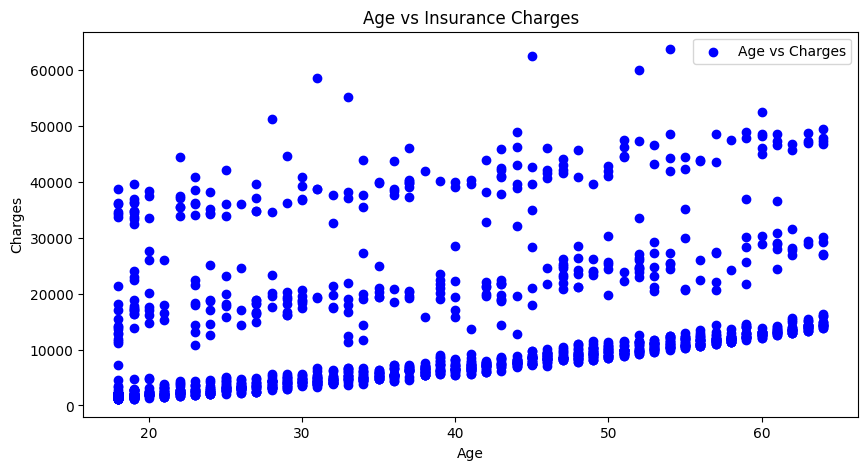

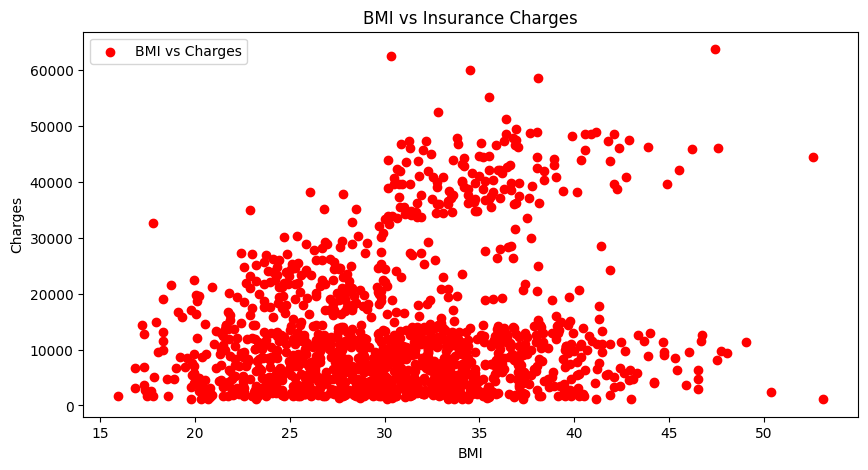

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(insurance_numeric['age'], Y_ins, color='blue', label='Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Insurance Charges')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(insurance_numeric['bmi'], Y_ins, color='red', label='BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Insurance Charges')
plt.legend()
plt.show()